<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
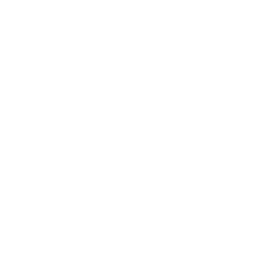
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Medication Error Rate EWMA Trend Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Healthcare / Patient Safety &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tämä analyysi seuraa viikoittaista lääkitysvirheiden määrää sairaalan teho-osastolla (ICU) käyttäen **eksponentiaalisesti painotettua liukuvaa keskiarvoa (EWMA) -ohjauskorttia** PROC MACONTROL -proseduurista. Teho-osastolla otettiin käyttöön uusi sähköinen lääkityksen antokirjaus (eMAR) -järjestelmä seurantajakson viikolla 51. Potilasturvallisuustiimit tarvitsevat varhaisvaroitusmenetelmän, joka tunnistaa nopeasti pysyvän virhemäärän nousun, ennen kuin haittatapahtumailmoituksia ehtii kertyä merkittävä määrä.

EWMA-kaavio, jonka tasoituspaino on **lambda = 0,3**, rakennetaan kahdessa vaiheessa. Ohjausrajat määritetään ensin vakaasta, ennen käyttöönottoa vallinneesta lähtötasosta (viikot 1-50), minkä jälkeen koko 100 viikon sarjaa seurataan näitä kiinteitä rajoja vasten. Kaavio pysyy hallinnassa koko lähtötasojakson ajan ja antaa hälytyksen hallinnasta poikkeavasta tilasta **ensimmäisellä viikolla käyttöönoton jälkeen**, mikä vahvistaa, että eMAR-siirtymä ajoittui yhteen todellisen, pysyvän virhetason muutoksen kanssa eikä kyse ollut tavanomaisesta viikoittaisesta kohinasta.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Viikoittainen lääkitysvirheiden määrä per 1 000 annostusta yhdelle teho-osastolle, 100 peräkkäistä viikkoa | 100 |

Yhtä teho-osastoa seurataan viikoittain. Jokainen tietue sisältää viikkonumeron, virhemäärän per 1 000 annostusta, annostusten määrän ja siitä johdetun virheiden lukumäärän. Dokumentoitu prosessimuutos (eMAR-käyttöönotto) tapahtuu viikolla 51, mikä nostaa taustalla olevan virhetason keskiarvoa noin 1,6 per 1 000.

---

In [1]:
/* --------------------------------------------------------
   Luo viikoittainen teho-osaston lääkitysvirheaineisto
   100 peräkkäistä viikkoa yhdelle teho-osastolle.
   Uusi eMAR-järjestelmä otetaan käyttöön viikolla 51, mikä
   nostaa taustalla olevan virhetason keskiarvon noin
   3,5:stä noin 5,1:een per 1 000.
   -------------------------------------------------------- */
TIEDOT work.icu_errors;
    CALL streaminit(42);
    PITUUS unit_name $12 phase $20;
    unit_name = 'TEHO';
    base_rate  = 3.5;   /* virhetaso ennen käyttöönottoa / 1 000 */
    unit_sigma = 0.45;  /* viikoittainen tavanomainen kohina */
    TEE week_num = 1 ASTI 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        JOS administrations < 300 NIIN administrations = 300;
        /* eMAR-siirtymä nostaa keskiarvoa viikon 50 jälkeen */
        JOS week_num > 50 NIIN TEE;
            phase = 'EMAR-JÄLKEEN';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        LOPPU;
        MUUTEN TEE;
            phase = 'LÄHTÖTASO';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        LOPPU;
        JOS error_rate_per_1k < 0 NIIN error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        TULOSTE;
    LOPPU;
    POISTA base_rate unit_sigma;
    MUOTO week_start_date date9.;
SUORITA;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                            Teho-osaston virhetaso: lähtötaso vs. eMAR-käyttöönoton jälkeen                             

                                                  The MEANS Procedure

                                Analysis Variable : error_rate_per_1k Virheitä / 1 000

        Vaihe                  N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        EMAR-JÄLKEEN              50           5.11           0.44           3.69           5.96
        LÄHTÖTASO                 50           3.50           0.48           2.55           4.71
        ----------------------------------------------------------------------------------------

                                 Analysis Variable : error_count Virheiden lukumäärä

        Vaihe                  N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


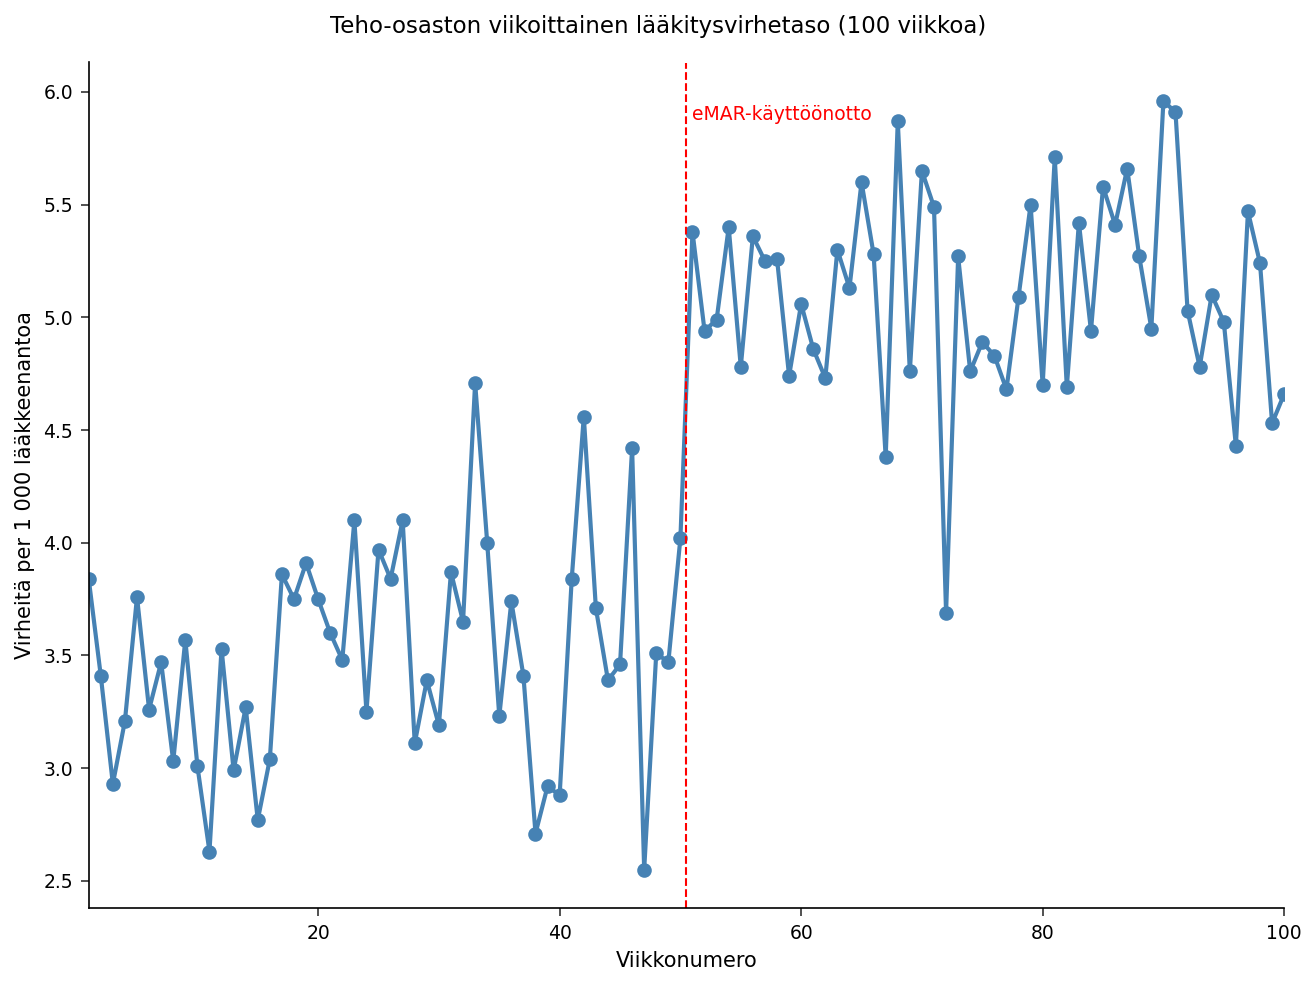

In [2]:
/* --------------------------------------------------------
   Vertaa virhetasoa ennen ja jälkeen eMAR-käyttöönoton,
   ja piirrä viikoittainen trendi.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.icu_errors n mean std MIN MAX maxdec=2;
    LUOKKA phase;
    MUUTTUJA error_rate_per_1k error_count administrations;
    NIMIKE phase='Vaihe' error_rate_per_1k='Virheitä / 1 000'
          error_count='Virheiden lukumäärä' administrations='Lääkkeenantoja';
    OTSIKKO 'Teho-osaston virhetaso: lähtötaso vs. eMAR-käyttöönoton jälkeen';
SUORITA;

PROSEDUURI SGPLOT TIEDOT=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   NIMIKE='eMAR-käyttöönotto';
    XAXIS NIMIKE='Viikkonumero';
    YAXIS NIMIKE='Virheitä per 1 000 lääkkeenantoa';
    OTSIKKO 'Teho-osaston viikoittainen lääkitysvirhetaso (100 viikkoa)';
SUORITA;

---

In [3]:
/* --------------------------------------------------------
   Vaihe I: määritä EWMA-ohjausrajat vakaasta, ennen
   käyttöönottoa vallinneesta lähtötasosta (viikot 1-50).
   Näistä kiinteistä rajoista tulee koko seurantajakson
   mittapuu.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.icu_errors(MISSÄ=(week_num <= 50)) NOPRINT;
    MUUTTUJA error_rate_per_1k;
    TULOSTE out=work.baseline_stats mean=base_mean std=base_std;
SUORITA;

TIEDOT work.icu_limits;
    ASETA work.baseline_stats;
    PITUUS _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* lähtötason keskilinja */
    _STDDEV_ = base_std;    /* lähtötason tavanomainen sigma */
    _LIMITN_ = 1;
    SÄILYTÄ _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.icu_limits noobs;
    OTSIKKO 'Vaihe I: ohjausrajojen syöttötiedot (lähtötaso, viikot 1-50)';
SUORITA;

                              Vaihe I: ohjausrajojen syöttötiedot (lähtötaso, viikot 1-50)                              

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                              Vaihe I: ohjausrajojen syöttötiedot (lähtötaso, viikot 1-50)                              


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/8324e6a7-b920-4609-bdc4-98ed0adc7d5f/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


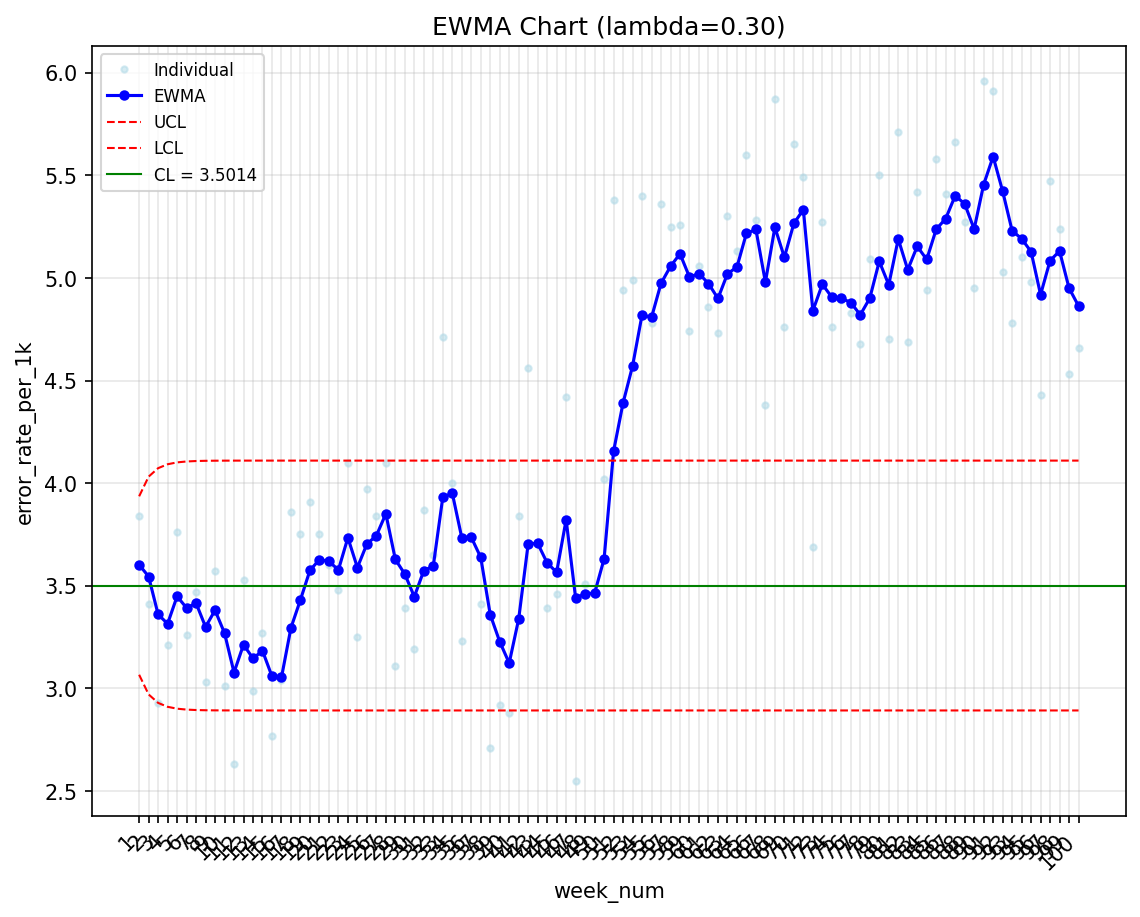

In [4]:
/* --------------------------------------------------------
   Vaihe II: seuraa koko 100 viikon sarjaa kiinteitä
   lähtötasorajoja vasten. lambda=0.3 antaa herkän
   havainnoinnin potilasturvallisuuden seurantaan.
   -------------------------------------------------------- */
PROSEDUURI macontrol TIEDOT=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        PAINO    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    NIMIKE error_rate_per_1k =
          'Lääkitysvirheitä per 1 000 lääkkeenantoa';
    OTSIKKO 'EWMA-kaavio: teho-osaston lääkitysvirhetaso (lambda=0,3)';
SUORITA;

---

In [5]:
/* --------------------------------------------------------
   Tunnista jokainen viikko, jolloin EWMA ylittää
   lähtötasorajat, ja raportoi ensimmäinen hälytysviikko.
   -------------------------------------------------------- */
TIEDOT work.signals;
    ASETA work.icu_table;
    MISSÄ _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
SUORITA;

PROSEDUURI SQL;
    VALITSE count(*)        AS n_signals          NIMIKE='Signaaliviikkoja',
           MIN(week_num)    AS first_signal_week  NIMIKE='Ensimmäinen signaaliviikko',
           MAX(_EWMA_)      AS peak_ewma MUOTO=6.3 NIMIKE='EWMA-huippu'
    FROM work.signals;
QUIT;

PROSEDUURI TULOSTA TIEDOT=work.signals(obs=8);
    MUUTTUJA week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    NIMIKE week_num='Viikko' error_rate_per_1k='Virheitä / 1 000';
    OTSIKKO 'Ensimmäiset hallinnasta poikkeavat EWMA-signaalit';
SUORITA;

                              Vaihe I: ohjausrajojen syöttötiedot (lähtötaso, viikot 1-50)                              

Signaaliviikkoja   Ensimmäinen signaaliviikko  EWMA-huippu
----------------  ---------------------------  -----------
              50                         51.0        5.591
                                   Ensimmäiset hallinnasta poikkeavat EWMA-signaalit                                    

  Obs  Viikko    _EWMA_   _UCLE_  _EXLIM_
    1      51  4.155551  4.10998        1
    2      52  4.390886  4.10998        1
    3      53   4.57062  4.10998        1
    4      54  4.819434  4.10998        1
    5      55  4.807604  4.10998        1
    6      56  4.973323  4.10998        1
    7      57  5.056326  4.10998        1
    8      58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Tulkinta

Kaksivaiheinen EWMA-analyysi erottaa selkeästi tavanomaisen viikoittaisen vaihtelun todellisesta prosessimuutoksesta eMAR-käyttöönoton yhteydessä.

**Lähtötaso (viikot 1-50).** PROC MEANS raportoi lähtötason keskimääräiseksi virhetasoksi **3,50 per 1 000 annostusta** (keskihajonta 0,48), kun taas käyttöönoton jälkeinen keskiarvo on **5,11** (keskihajonta 0,44) -- pysyvä nousu noin **1,6 virhettä per 1 000**. Annostusten määrä on samankaltainen molemmissa vaiheissa (795 vs. 790 viikossa), joten muutos heijastaa virhe*tasoa*, ei työmäärän vaihtelua.

**Ohjausrajat.** Rajat määritetään yksinomaan lähtötason perusteella: keskilinja **3,5014**, lähtötason sigma **0,4829**. Tasoituspainolla lambda = 0,3 ja 3-sigman rajoilla EWMA:n yläraja asettuu asymptoottiseen arvoonsa, noin **4,11**. Viikkojen 1-50 ajan EWMA-tunnusluku pysyy näiden rajojen sisällä -- lähtötaso ei tuota **yhtään väärää hälytystä**, mikä vahvistaa, ettei kaavio ole liian herkkä.

**Havaitseminen.** Kaavio antaa hälytyksen hallinnasta poikkeavasta tilasta **jo ensimmäisellä viikolla käyttöönoton jälkeen (viikko 51)**, jolloin EWMA saavuttaa arvon **4,156**, juuri rajan 4,11 yläpuolella. Siitä eteenpäin tunnusluku nousee tasaisesti ja pysyy ylärajan yläpuolella koko käyttöönoton jälkeisen ajanjakson: **kaikki 50 käyttöönoton jälkeistä viikkoa (51-100) antavat signaalin**, ja EWMA huipentuu arvoon **5,591** noin viikolla 91. Lambda = 0,3:n reagointiherkkyys tarkoittaa, että heikkeneminen havaitaan välittömästi eikä vasta usean viikon kertymän jälkeen.

**Toimenpide.** Pysyvä EWMA-rajan ylitys, joka alkaa samalla viikolla kuin eMAR-käyttöönotto, on vahva näyttö siitä, että juuri uusi järjestelmä -- ei sattuma -- aiheutti nousun. Potilasturvallisuuskomitean tulisi käsitellä viikkoa 51 muutoskohtana, auditoida kyseisellä viikolla käyttöönotetut eMAR-lääkemääräys- ja ohitustyönkulut, ja pitää kaavio käynnissä alkuperäisiä lähtötasorajoja vasten, kunnes EWMA palaa alle arvon 4,11. Viety `icu_ewma_signals.csv` (50 signaaliviikkoa) ja `icu_ewma_table.csv` tarjoavat dokumentoidun SPC-näyttöketjun Joint Commissionin jatkuvaan valmiuden arviointiin.

---

In [6]:
/* --------------------------------------------------------
   Vie EWMA-taulukko ja signaaliluettelo Joint Commission
   -jatkuvan valmiuden dokumentaatiota varten.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu käyttäen <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenneriä</a>
</div>
</div>